In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# imports
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

from matplotlib import pyplot as plt
import numpy as np
from equayes import Equayes, PROJECT_ROOT
from equayes.core.pyro_backend import utils as pyro_utils
from equayes.visualisation import predictive_plotting as pred_plot
from equayes.core.sympy_backend import utils as sp_utils

import sympy as sp
import torch
import os
import arviz as az
import pyro
import torch
import pandas as pd

In [3]:
import matplotlib as mpl

font_size_small = 12
font_size_big = 14

mpl.rcParams["legend.fontsize"] = font_size_big  # legend labels
mpl.rcParams["axes.labelsize"] = font_size_big  # x/y axis labels
mpl.rcParams["xtick.labelsize"] = font_size_small  # x tick labels
mpl.rcParams["ytick.labelsize"] = font_size_small

Text(0, 0.5, 'y')

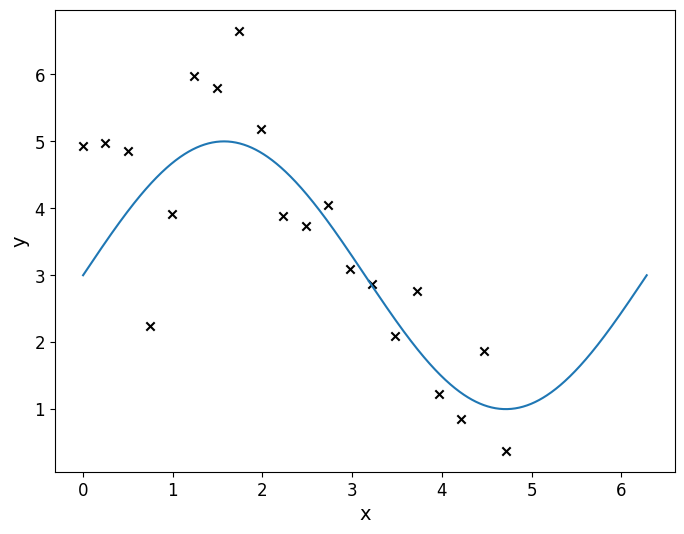

In [4]:
# create data
N_train = 20
N_test = 1000
seed = 42

noise_sigma = 1.0
np.random.seed(seed)
torch.manual_seed(seed)


def synthetic_function_1d(x, noise_sigma=1.0):
    y = 2 * torch.sin(x) + 3
    y_obs = y + torch.randn(x.shape if len(x) > 0 else (1,)) * noise_sigma
    return y, y_obs


x_train = torch.linspace(0, 3 * np.pi / 2, steps=N_train)
x_test = torch.linspace(0, 4 * np.pi / 2, steps=N_test)

y_train, y_obs_train = synthetic_function_1d(x_train, noise_sigma)
y_test, y_obs_test = synthetic_function_1d(x_test, noise_sigma)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.scatter(x_train, y_obs_train, marker="x", color="black")
plt.plot(x_test, y_test, label="True Function")
plt.xlabel("x")
plt.ylabel("y")

In [5]:
# define sympy expression
x0 = sp.Symbol("x0")

expr_sp_true = 2.0 * sp.sin(x0) + 3.0
expr_sp_quadratic = 2.0 * x0**2 - 1.1 * x0 + 5.0

polynomial_degree = 3
expr_polynomial = 1.0
for i in range(1, polynomial_degree + 1):
    expr_polynomial = np.random.randn() * 1 / (2 * i) * x0**i + expr_polynomial
print(expr_polynomial)

selected_expression = expr_polynomial  

0.107948089683449*x0**3 - 0.0345660752927962*x0**2 + 0.248357076505616*x0 + 1.0


tensor(162.8083, grad_fn=<MseLossBackward0>)
tensor(0.0949, grad_fn=<MseLossBackward0>)
tensor(0.0362, grad_fn=<MseLossBackward0>)
tensor(0.0208, grad_fn=<MseLossBackward0>)
tensor(0.0174, grad_fn=<MseLossBackward0>)
tensor(0.0166, grad_fn=<MseLossBackward0>)
tensor(0.0164, grad_fn=<MseLossBackward0>)
tensor(0.0164, grad_fn=<MseLossBackward0>)
tensor(0.0164, grad_fn=<MseLossBackward0>)
tensor(0.0163, grad_fn=<MseLossBackward0>)
tensor(0.0163, grad_fn=<MseLossBackward0>)
tensor(0.0163, grad_fn=<MseLossBackward0>)
tensor(0.0163, grad_fn=<MseLossBackward0>)
tensor(0.0163, grad_fn=<MseLossBackward0>)
p0*x0**3 - p1*x0**2 + p2*x0 + p3
p0 tensor(0.1665)
p1 tensor(1.6242)
p2 tensor(3.5514)
p3 tensor(2.7364)


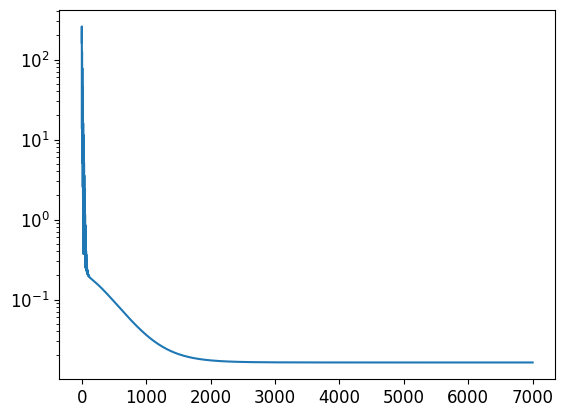

In [6]:
# deterministic fit

np.random.seed(seed)
torch.manual_seed(seed)
expr_sp_parameterized, exp_param_values = sp_utils.replace_floats_in_print_order(selected_expression)
expr_torch_with_params = sp.lambdify([x0] + list(exp_param_values.keys()), expr_sp_parameterized, modules=["torch"])

# learnable torch parameters
params = torch.nn.ParameterList([torch.nn.Parameter(torch.randn(())) for _ in range(len(exp_param_values))])

# gradient descent MLE fit
n_iter = 7000
lr = 5e-1
lrd = 1e-2
optim = torch.optim.Adam(params, lr=lr)
loss_function = torch.nn.MSELoss()
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, gamma=lrd ** (1 / n_iter))
losses = []
for i in range(n_iter):
    optim.zero_grad()

    y_pred = expr_torch_with_params(x_train, *params)
    loss = loss_function(y_pred, y_train)

    loss.backward()
    optim.step()
    lr_scheduler.step()
    losses.append(loss.detach())
    if i % 500 == 0:
        print(loss)

plt.plot(np.linspace(0, n_iter, n_iter), torch.tensor(losses))
plt.yscale("log")

print(expr_sp_parameterized)
for i, latent_var in enumerate(list(exp_param_values.keys())):
    print(latent_var, params[i].detach())

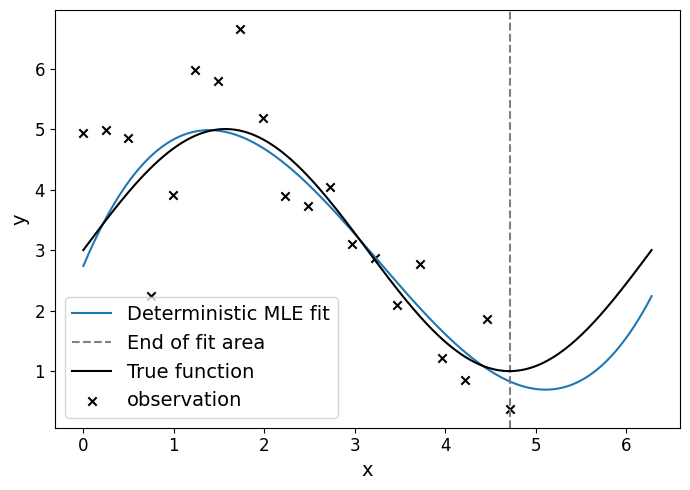

In [7]:
# eval deterministic fit
y_pred_test = expr_torch_with_params(x_test, *params).detach()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(x_test, y_pred_test, label="Deterministic MLE fit")
ax.axvline(3 / 2 * np.pi, linestyle="--", color="grey", label="End of fit area")
ax.plot(x_test, y_test, label="True function", color="black")
ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
os.makedirs(f"{PROJECT_ROOT}/output/", exist_ok=True)
plt.savefig(f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_prediction_deterministic.png")

In [ ]:
expr_polynomial_from_det_solution = 0.0
for i in range(0, polynomial_degree + 1):
    if str(expr_sp_parameterized).startswith(("(-", "-")):
        expr_polynomial_from_det_solution = -params[i] * x0 ** (polynomial_degree - i) + expr_polynomial_from_det_solution
    else:
        expr_polynomial_from_det_solution = params[i] * x0 ** (polynomial_degree - i) + expr_polynomial_from_det_solution

print(expr_polynomial_from_det_solution)

In [ ]:
inference_method_name = "vi"
kernel_name = ""
equayes = Equayes(
    expr=selected_expression,
    input_symbols=[x0],
    output_dim=1,
    inference_method_name=inference_method_name,
    kernel_name=kernel_name,
    mcmc_samples=1000,
    mcmc_warmup_samples=1000,
    vi_iter=3000,
    vi_lr=1e-1,
    vi_lrd=1e-1,
    vi_particles=16,
    jit_compile=True,
)

losses_optional = equayes.fit(x_train.view((-1, 1)), y_obs_train.view((-1, 1)))
if losses_optional is not None:
    plt.plot(np.linspace(0, equayes.vi_iter, equayes.vi_iter), losses_optional)
    plt.yscale("log")

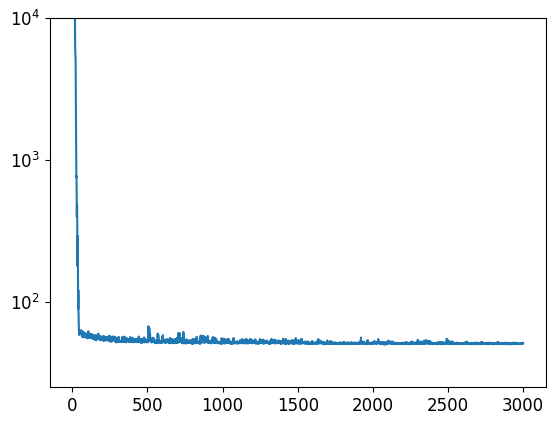

In [10]:
if losses_optional is not None:
    plt.plot(np.linspace(0, equayes.vi_iter, equayes.vi_iter), losses_optional)
    plt.yscale("symlog")
    plt.ylim(torch.tensor(losses_optional).min() * 0.5, 1e4)

In [11]:
equayes.predict(x_train.view((-1, 1)), sample_prior=False, parallel=True)["mu"].shape

torch.Size([500, 1, 20, 1])

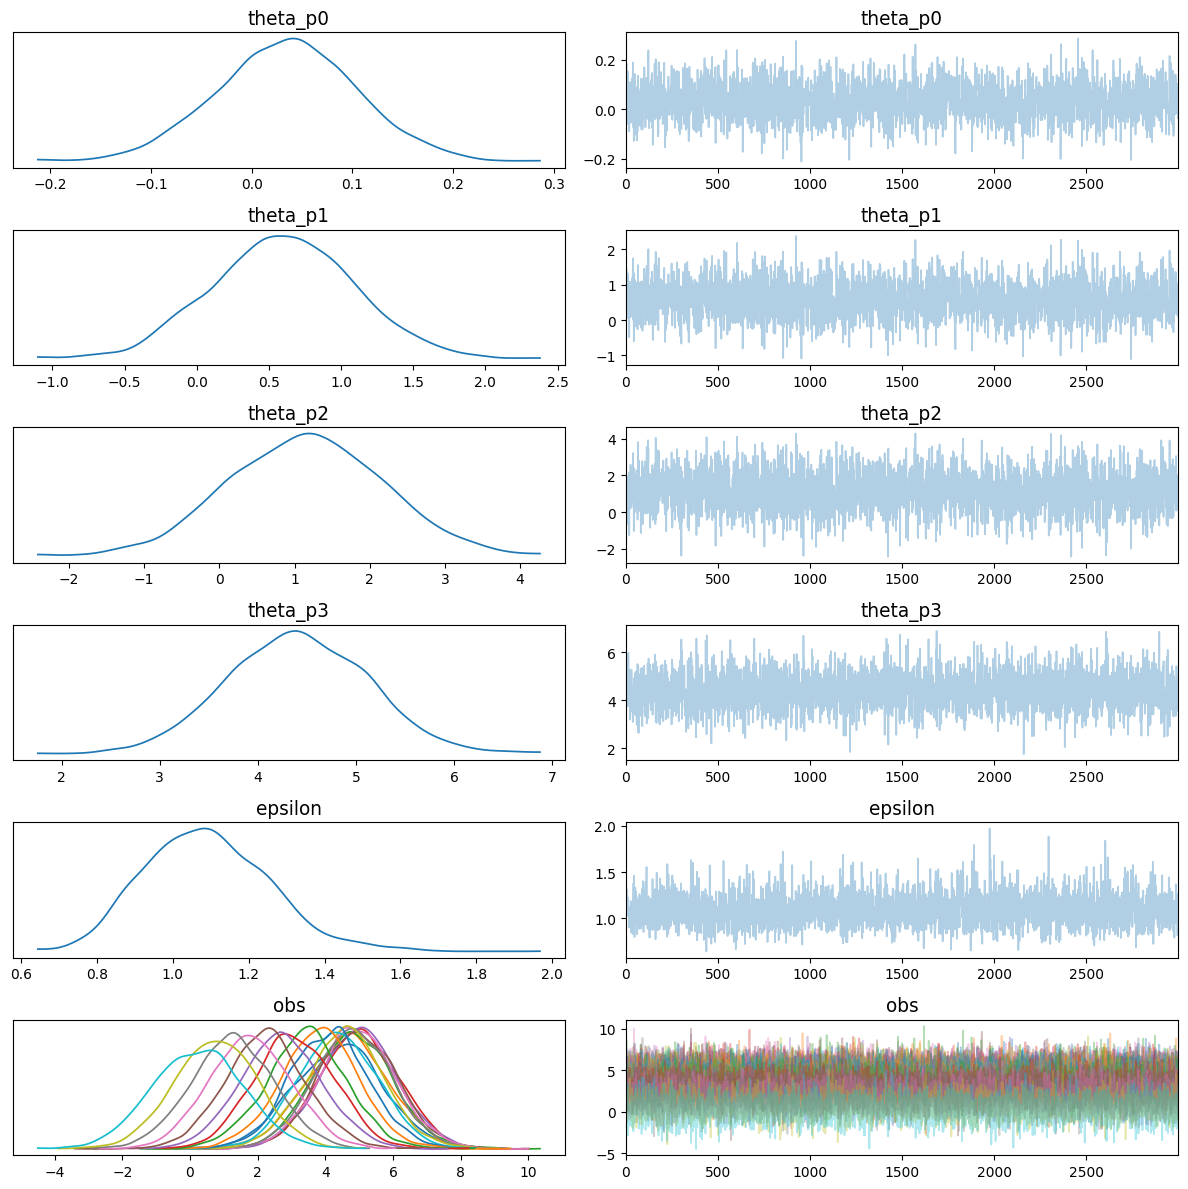

In [12]:
# Evaluation
os.makedirs(f"{PROJECT_ROOT}/output", exist_ok=True)

equayes.inference_diagnostics()

idata = equayes.get_posterior()
if type(idata) is not az.InferenceData:
    idata = pyro_utils.guide_to_inference_data(equayes._pyro_model, equayes._guide, x_train.view((-1, 1)), num_samples=3000)

az.plot_trace(idata)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_posterior_{inference_method_name}_{kernel_name}.png")
#

torch.Size([500, 1, 1000, 1])


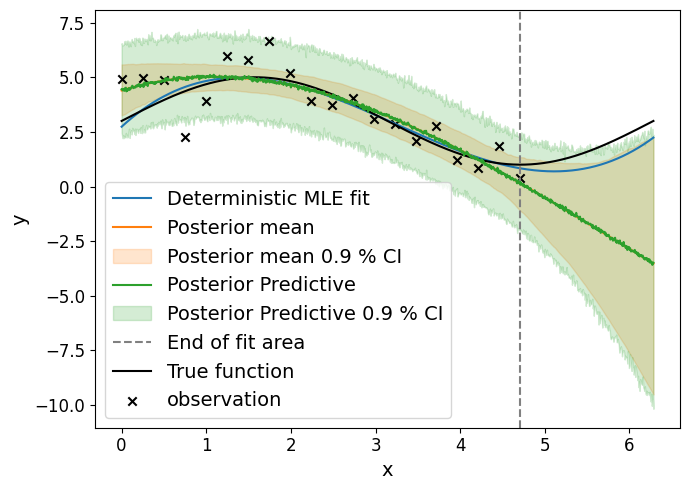

In [13]:
pred_samples = equayes.predict(x_test.view(-1, 1), n_predictive_samples=500, parallel=True)
print(pred_samples["mu"].shape)
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.plot(x_test, y_pred_test, label="Deterministic MLE fit")
ax = pred_plot.plot_1d_predictive_density(x_test.numpy(), pred_samples["mu"].squeeze().numpy(), label="Posterior mean", ax=ax)
ax = pred_plot.plot_1d_predictive_density(
    x_test.numpy(), pred_samples["obs"].squeeze().numpy(), label="Posterior Predictive", ax=ax
)
ax.axvline(3 / 2 * np.pi, linestyle="--", color="grey", label="End of fit area")

ax.plot(x_test, y_test, label="True function", color="black")
ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.legend()
plt.tight_layout()

plt.savefig(f"{PROJECT_ROOT}/output/degree_{polynomial_degree}_post_pred_{inference_method_name}_{kernel_name}.png")